### Forecasting Dataset Loading and Quality Check

The XGBoost forecasting model used the processed daily water-climate dataset generated during preprocessing. The dataset contains complete daily records for ten lakes from 2006 to 2025, with water level, precipitation and mean temperature variables used for forecasting.

Snow water equivalent (WESD) was retained separately with an availability indicator but was not included as a primary forecasting predictor because of inconsistent spatial coverage across lakes.

In [1]:
# Load forecasting input dataset

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Identify the repository root
current_dir = Path.cwd()

if (
    current_dir
    / "data"
    / "processed"
    / "water_climate_10_lakes_primary.csv"
).exists():

    PROJECT_ROOT = current_dir

elif (
    current_dir.parent
    / "data"
    / "processed"
    / "water_climate_10_lakes_primary.csv"
).exists():

    PROJECT_ROOT = current_dir.parent

else:
    raise FileNotFoundError(
        "Repository root could not be identified. "
        "Run this notebook from the repository root "
        "or from the notebooks directory."
    )


processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

forecast_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "forecasting_results"
)

forecast_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


primary_data_file = (
    processed_path
    / "water_climate_10_lakes_primary.csv"
)


water_climate = pd.read_csv(
    primary_data_file,
    parse_dates=["Date"]
)


print(
    "Forecasting dataset loaded successfully."
)

print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Dataset shape:",
    water_climate.shape
)

print(
    "Date range:",
    water_climate["Date"].min(),
    "to",
    water_climate["Date"].max()
)

print(
    "Number of lakes:",
    water_climate["Lake"].nunique()
)

Forecasting dataset loaded successfully.
Project root: D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final
Dataset shape: (73050, 8)
Date range: 2006-01-01 00:00:00 to 2025-12-31 00:00:00
Number of lakes: 10


In [2]:
# Basic forecasting input quality checks


required_columns = {"Date",
    "Lake",
    "Lake_Level_ft",
    "PRCP",
    "TMEAN"
    }


missing_required_columns = (
    required_columns
    - set(water_climate.columns)
)


if missing_required_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_required_columns)}"
    )


if water_climate.duplicated(
    ["Date", "Lake"]
).any():
    raise ValueError(
        "Duplicate Date-Lake records were found."
    )


water_climate = (
    water_climate
    .sort_values(
        ["Lake", "Date"]
    )
    .reset_index(drop=True)
)


print(
    "Missing lake-level observations by lake:"
)

print(
    water_climate
    .groupby("Lake")["Lake_Level_ft"]
    .apply(
        lambda x: x.isna().sum()
    )
)

Missing lake-level observations by lake:
Lake
Great Salt Lake      0
Lake Champlain       0
Lake Erie            0
Lake Huron          30
Lake Michigan        0
Lake Ontario        30
Lake Superior       31
Lake Tahoe           0
Lake Woods          21
Red Lake           167
Name: Lake_Level_ft, dtype: int64


In [3]:
expected_primary_missing = {
    "Lake Superior": 31,
    "Lake Huron": 30,
    "Lake Michigan": 0,
    "Lake Erie": 0,
    "Lake Ontario": 30,
    "Lake Woods": 21,
    "Great Salt Lake": 0,
    "Lake Champlain": 0,
    "Red Lake": 167,
    "Lake Tahoe": 0
}


observed_primary_missing = (
    water_climate
    .groupby("Lake")["Lake_Level_ft"]
    .apply(
        lambda x: x.isna().sum()
    )
    .reindex(
        expected_primary_missing.keys()
    )
    .astype(int)
    .to_dict()
)


if (
    observed_primary_missing
    != expected_primary_missing
):
    raise ValueError(
        "The loaded file does not match "
        "the locked ERP-1 primary "
        "water-level dataset. "
        f"Observed missing counts: "
        f"{observed_primary_missing}"
    )


if len(water_climate) != 73050:
    raise ValueError(
        "Expected 73,050 Date-Lake rows "
        "in the final daily dataset."
    )


print(
    "Primary forecasting input QC passed."
)

Primary forecasting input QC passed.


In [4]:
# Check daily continuity for each lake

date_check = (
    water_climate
    .groupby("Lake")["Date"]
    .agg(
        start="min",
        end="max",
        count="count"
    )
)

display(
    date_check
)

,start,end,count
Lake,,,
Great Salt Lake,2006-01-01,2025-12-31,7305
Lake Champlain,2006-01-01,2025-12-31,7305
Lake Erie,2006-01-01,2025-12-31,7305
Lake Huron,2006-01-01,2025-12-31,7305
Lake Michigan,2006-01-01,2025-12-31,7305
Lake Ontario,2006-01-01,2025-12-31,7305
Lake Superior,2006-01-01,2025-12-31,7305
Lake Tahoe,2006-01-01,2025-12-31,7305
Lake Woods,2006-01-01,2025-12-31,7305


In [5]:
# Define and validate the established lake order

lake_order = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario",
    "Lake Woods",
    "Great Salt Lake",
    "Lake Tahoe",
    "Red Lake",
    "Lake Champlain"
]


observed_lakes = set(
    water_climate["Lake"]
    .dropna()
    .unique()
)


expected_lakes = set(
    lake_order
)


if observed_lakes != expected_lakes:

    missing_lakes = (
        expected_lakes
        - observed_lakes
    )

    unexpected_lakes = (
        observed_lakes
        - expected_lakes
    )

    raise ValueError(
        "Lake names do not match the "
        "established ten-lake dataset. "
        f"Missing: {sorted(missing_lakes)}; "
        f"Unexpected: {sorted(unexpected_lakes)}"
    )


water_climate["Lake"] = pd.Categorical(
    water_climate["Lake"],
    categories=lake_order,
    ordered=True
)


print(
    "Lake order validated:"
)

print(
    lake_order
)

Lake order validated:
['Lake Superior', 'Lake Huron', 'Lake Michigan', 'Lake Erie', 'Lake Ontario', 'Lake Woods', 'Great Salt Lake', 'Lake Tahoe', 'Red Lake', 'Lake Champlain']


In [6]:
# Create the base XGBoost dataset and define forecasting periods

xgb_base_data = (
    water_climate[
        [
            "Date",
            "Lake",
            "Lake_Level_ft",
            "PRCP",
            "TMEAN"
        ]
    ]
    .copy()
    .sort_values(
        by=[
            "Lake",
            "Date"
        ]
    )
    .reset_index(drop=True)
)


# Define chronological modelling periods

parameter_train_start = pd.Timestamp(
    "2006-01-01"
)

parameter_train_end = pd.Timestamp(
    "2018-12-31"
)

validation_start = pd.Timestamp(
    "2019-01-01"
)

validation_end = pd.Timestamp(
    "2021-12-31"
)

final_test_start = pd.Timestamp(
    "2022-01-01"
)

final_test_end = pd.Timestamp(
    "2025-12-31"
)


print(
    "XGBoost base data shape:",
    xgb_base_data.shape
)

print(
    "Parameter training:",
    parameter_train_start,
    "to",
    parameter_train_end
)

print(
    "Validation:",
    validation_start,
    "to",
    validation_end
)

print(
    "Final test:",
    final_test_start,
    "to",
    final_test_end
)

XGBoost base data shape: (73050, 5)
Parameter training: 2006-01-01 00:00:00 to 2018-12-31 00:00:00
Validation: 2019-01-01 00:00:00 to 2021-12-31 00:00:00
Final test: 2022-01-01 00:00:00 to 2025-12-31 00:00:00


## 1. Feature Engineering

XGBoost features were designed to represent three components of lake-level dynamics: historical persistence, annual seasonality and meteorological conditions. Lagged water-level variables captured short-term and annual temporal dependence, while sine and cosine terms represented the recurring seasonal cycle. PRCP and TMEAN were included as contemporaneous meteorological predictors.Model-fitting samples were restricted to observations for which the target and required predictor values were available.

In [7]:
# Define XGBoost features

level_lags = [
    1,
    7,
    14,
    30,
    365
]


def create_xgb_features(
    lake_data
):
    """Create temporal, seasonal and meteorological XGBoost features."""

    data = (
        lake_data
        .copy()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # Lagged lake-level features
    for lag in level_lags:

        data[
            f"Lake_Level_lag{lag}"
        ] = (
            data["Lake_Level_ft"]
            .shift(lag)
        )

    # Annual seasonal features
    day_of_year = (
        data["Date"]
        .dt.dayofyear
    )

    data["Annual_sin"] = np.sin(
        2
        * np.pi
        * day_of_year
        / 365.25
    )

    data["Annual_cos"] = np.cos(
        2
        * np.pi
        * day_of_year
        / 365.25
    )

    return data


xgb_feature_columns = [
    "Lake_Level_lag1",
    "Lake_Level_lag7",
    "Lake_Level_lag14",
    "Lake_Level_lag30",
    "Lake_Level_lag365",
    "PRCP",
    "TMEAN",
    "Annual_sin",
    "Annual_cos"
]


print(
    "Number of XGBoost features:",
    len(xgb_feature_columns)
)

print(
    xgb_feature_columns
)

Number of XGBoost features: 9
['Lake_Level_lag1', 'Lake_Level_lag7', 'Lake_Level_lag14', 'Lake_Level_lag30', 'Lake_Level_lag365', 'PRCP', 'TMEAN', 'Annual_sin', 'Annual_cos']


## 2.Lake Superior Prototype

Lake Superior was used to demonstrate the XGBoost feature-construction, model-selection and recursive forecasting procedure before the same workflow was applied independently to all ten lakes.

In [8]:
# Prepare Lake Superior data

target_lake = "Lake Superior"

superior_xgb_data = (
    xgb_base_data[
        xgb_base_data["Lake"]
        == target_lake
    ]
    .copy()
)

superior_xgb_data = (
    create_xgb_features(
        superior_xgb_data
    )
)

display(
    superior_xgb_data[
        [
            "Date",
            "Lake_Level_ft"
        ]
        + xgb_feature_columns
    ]
    .head()
)

,Date,Lake_Level_ft,Lake_Level_lag1,Lake_Level_lag7,Lake_Level_lag14,Lake_Level_lag30,Lake_Level_lag365,PRCP,TMEAN,Annual_sin,Annual_cos
0,2006-01-01,601.63,NaN,NaN,NaN,NaN,NaN,0.3,-5.85,0.017202,0.999852
1,2006-01-02,601.48,601.63,NaN,NaN,NaN,NaN,2.5,-1.10,0.034398,0.999408
2,2006-01-03,601.33,601.48,NaN,NaN,NaN,NaN,0.0,0.30,0.051584,0.998669
3,2006-01-04,601.32,601.33,NaN,NaN,NaN,NaN,0.0,-1.35,0.068755,0.997634
4,2006-01-05,601.33,601.32,NaN,NaN,NaN,NaN,0.0,-3.60,0.085906,0.996303


In [9]:
# Create parameter-training data for Lake Superior

superior_parameter_train = (
    superior_xgb_data[
        (
            superior_xgb_data["Date"]
            >= parameter_train_start
        )
        &
        (
            superior_xgb_data["Date"]
            <= parameter_train_end
        )
    ]
    .dropna(
        subset=
            xgb_feature_columns
            + ["Lake_Level_ft"]
    )
    .copy()
)

X_parameter_train = (
    superior_parameter_train[
        xgb_feature_columns
    ]
)

y_parameter_train = (
    superior_parameter_train[
        "Lake_Level_ft"
    ]
)

print(
    "Parameter-training observations:",
    len(
        superior_parameter_train
    )
)

print(
    "Features:",
    X_parameter_train.shape[1]
)

print(
    "Training period:",
    superior_parameter_train[
        "Date"
    ].min(),
    "to",
    superior_parameter_train[
        "Date"
    ].max()
)

Parameter-training observations: 4383
Features: 9
Training period: 2007-01-01 00:00:00 to 2018-12-31 00:00:00


In [10]:
# Import XGBoost

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# Define forecast evaluation metrics

def calculate_forecast_metrics(
    actual,
    predicted
):
    """Align actual and predicted series and calculate forecast metrics."""

    actual = (
        pd.Series(actual)
        .astype(float)
        .copy()
    )

    if isinstance(
        predicted,
        pd.Series
    ):

        predicted = (
            predicted
            .astype(float)
            .copy()
        )

    else:

        predicted_array = np.asarray(
            predicted,
            dtype=float
        )

        if (
            len(predicted_array)
            != len(actual)
        ):
            raise ValueError(
                "Actual and predicted values have different lengths."
            )

        predicted = pd.Series(
            predicted_array,
            index=actual.index,
            dtype=float
        )


    evaluation_data = pd.concat(
        [
            actual.rename("Actual"),
            predicted.rename("Predicted")
        ],
        axis=1
    ).dropna()


    if evaluation_data.empty:
        raise ValueError(
            "No aligned observations are available for evaluation."
        )


    if not np.isfinite(
        evaluation_data["Predicted"]
    ).all():
        raise FloatingPointError(
            "Forecast contains non-finite values."
        )


    rmse = np.sqrt(
        mean_squared_error(
            evaluation_data["Actual"],
            evaluation_data["Predicted"]
        )
    )

    mae = mean_absolute_error(
        evaluation_data["Actual"],
        evaluation_data["Predicted"]
    )

    r2 = r2_score(
        evaluation_data["Actual"],
        evaluation_data["Predicted"]
    )


    observed_sd = (
        evaluation_data[
            "Actual"
        ]
        .std()
    )

    nrmse = (
        rmse
        / observed_sd
        if observed_sd > 0
        else np.nan
    )


    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NRMSE": nrmse,
        "N_test": len(
            evaluation_data
        )
    }

## 3.Parameter Selection

In [11]:
# Define candidate XGBoost specifications

xgb_candidates = [
    {
        "max_depth": 2,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 500
    },
    {
        "max_depth": 4,
        "learning_rate": 0.03,
        "n_estimators": 500
    }
]

print(
    "Number of candidate models:",
    len(xgb_candidates)
)

# Define recursive XGBoost forecasting

def recursive_xgb_forecast(
    model,
    lake_data,
    forecast_start,
    forecast_end,
    feature_columns,
    level_lags
):

    lake_data = (
        lake_data
        .copy()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    lake_data = (
        lake_data
        .set_index("Date")
    )

    forecast_dates = pd.date_range(
        start=forecast_start,
        end=forecast_end,
        freq="D"
    )

    # Store only information available
    # before the forecast origin
    level_history = (
        lake_data.loc[
            lake_data.index
            < forecast_start,
            "Lake_Level_ft"
        ]
        .copy()
        .to_dict()
    )

    predictions = []

    for forecast_date in forecast_dates:

        feature_values = {}

        # Recursive lake-level lags
        for lag in level_lags:

            lag_date = (
                forecast_date
                - pd.Timedelta(
                    days=lag
                )
            )

            feature_values[
                f"Lake_Level_lag{lag}"
            ] = (
                level_history[
                    lag_date
                ]
            )

        # Observed contemporaneous climate
        feature_values["PRCP"] = (
            lake_data.loc[
                forecast_date,
                "PRCP"
            ]
        )

        feature_values["TMEAN"] = (
            lake_data.loc[
                forecast_date,
                "TMEAN"
            ]
        )

        day_of_year = (
            forecast_date.dayofyear
        )

        feature_values[
            "Annual_sin"
        ] = np.sin(
            2 * np.pi
            * day_of_year
            / 365.25
        )

        feature_values[
            "Annual_cos"
        ] = np.cos(
            2 * np.pi
            * day_of_year
            / 365.25
        )

        X_forecast = pd.DataFrame(
            [
                feature_values
            ],
            columns=
                feature_columns
        )

        predicted_level = float(
            model.predict(
                X_forecast
            )[0]
        )

        predictions.append(
            predicted_level
        )

        # Use the prediction as future history
        level_history[
            forecast_date
        ] = predicted_level

    return pd.Series(
        predictions,
        index=forecast_dates,
        name="XGBoost Forecast"
    )

Number of candidate models: 5


In [12]:
# Evaluate candidate XGBoost models on the validation period

xgb_validation_results = []

validation_actual = (
    superior_xgb_data
    .set_index("Date")
    .loc[
        validation_start:
        validation_end,
        "Lake_Level_ft"
    ]
)

for model_number, params in enumerate(
    xgb_candidates,
    start=1
):

    print(
        f"Evaluating XGBoost "
        f"{model_number}/"
        f"{len(xgb_candidates)}"
    )

    model = XGBRegressor(
        objective=
            "reg:squarederror",
        max_depth=
            params[
                "max_depth"
            ],
        learning_rate=
            params[
                "learning_rate"
            ],
        n_estimators=
            params[
                "n_estimators"
            ],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_parameter_train,
        y_parameter_train
    )

    validation_forecast = (
        recursive_xgb_forecast(
            model=model,
            lake_data=
                superior_xgb_data,
            forecast_start=
                validation_start,
            forecast_end=
                validation_end,
            feature_columns=
                xgb_feature_columns,
            level_lags=
                level_lags
        )
    )

    metrics = (
        calculate_forecast_metrics(
            actual=
                validation_actual,
            predicted=
                validation_forecast
        )
    )

    xgb_validation_results.append({
        "Max Depth":
            params[
                "max_depth"
            ],
        "Learning Rate":
            params[
                "learning_rate"
            ],
        "N Estimators":
            params[
                "n_estimators"
            ],
        "Validation RMSE":
            metrics["RMSE"],
        "Validation MAE":
            metrics["MAE"],
        "Validation R2":
            metrics["R2"]
    })


xgb_validation_summary = (
    pd.DataFrame(
        xgb_validation_results
    )
    .sort_values(
        by=[
            "Validation RMSE",
            "Validation MAE"
        ]
    )
    .reset_index(drop=True)
)

display(
    xgb_validation_summary
)

Evaluating XGBoost 1/5
Evaluating XGBoost 2/5
Evaluating XGBoost 3/5
Evaluating XGBoost 4/5
Evaluating XGBoost 5/5


,Max Depth,Learning Rate,N Estimators,Validation RMSE,Validation MAE,Validation R2
0,4,0.03,500,0.510964,0.440361,0.002272
1,4,0.05,300,0.511169,0.435675,0.001473
2,3,0.03,500,0.531596,0.459341,-0.079928
3,3,0.05,300,0.552282,0.469293,-0.165610
4,2,0.05,300,0.609920,0.501812,-0.421599


Five predefined XGBoost configurations were evaluated using the validation period. The configuration achieving the lowest validation RMSE was selected for final refitting.

In [13]:
# Select the best XGBoost specification

best_xgb_params = {
    "max_depth":
        int(
            xgb_validation_summary
            .loc[
                0,
                "Max Depth"
            ]
        ),

    "learning_rate":
        float(
            xgb_validation_summary
            .loc[
                0,
                "Learning Rate"
            ]
        ),

    "n_estimators":
        int(
            xgb_validation_summary
            .loc[
                0,
                "N Estimators"
            ]
        )
}

print(
    "Selected XGBoost parameters:",
    best_xgb_params
)

print(
    "Best validation RMSE:",
    round(
        xgb_validation_summary
        .loc[
            0,
            "Validation RMSE"
        ],
        4
    )
)

Selected XGBoost parameters: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500}
Best validation RMSE: 0.511


## 4. Cross-Lake Validation

The same five candidate configurations and recursive validation procedure were applied independently to all ten lakes. Hyperparameters were therefore selected separately for each lake using validation RMSE.

In [14]:
# Run lake-specific XGBoost validation across all ten lakes

cross_lake_xgb_results = []

for lake_name in lake_order:

    print(
        f"\nProcessing: {lake_name}"
    )

    lake_data = (
        xgb_base_data[
            xgb_base_data["Lake"]
            == lake_name
        ]
        .copy()
    )

    lake_data = create_xgb_features(
        lake_data
    )

    parameter_train_data = (
        lake_data[
            (
                lake_data["Date"]
                >= parameter_train_start
            )
            &
            (
                lake_data["Date"]
                <= parameter_train_end
            )
        ]
        .dropna(
            subset=
                xgb_feature_columns
                + ["Lake_Level_ft"]
        )
        .copy()
    )

    X_train = (
        parameter_train_data[
            xgb_feature_columns
        ]
    )

    y_train = (
        parameter_train_data[
            "Lake_Level_ft"
        ]
    )

    validation_actual = (
        lake_data
        .set_index("Date")
        .loc[
            validation_start:
            validation_end,
            "Lake_Level_ft"
        ]
    )

    lake_candidate_results = []

    for params in xgb_candidates:

        model = XGBRegressor(
            objective=
                "reg:squarederror",
            max_depth=
                params["max_depth"],
            learning_rate=
                params["learning_rate"],
            n_estimators=
                params["n_estimators"],
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train,
            y_train
        )

        validation_forecast = (
            recursive_xgb_forecast(
                model=model,
                lake_data=
                    lake_data,
                forecast_start=
                    validation_start,
                forecast_end=
                    validation_end,
                feature_columns=
                    xgb_feature_columns,
                level_lags=
                    level_lags
            )
        )

        metrics = (
            calculate_forecast_metrics(
                actual=
                    validation_actual,
                predicted=
                    validation_forecast
            )
        )

        lake_candidate_results.append({
            "Lake":
                lake_name,
            "Max Depth":
                params[
                    "max_depth"
                ],
            "Learning Rate":
                params[
                    "learning_rate"
                ],
            "N Estimators":
                params[
                    "n_estimators"
                ],
            "Validation N":
                metrics[
                    "N_test"
                ],
            "Validation RMSE":
                metrics[
                    "RMSE"
                ],
            "Validation MAE":
                metrics[
                    "MAE"
                ],
            "Validation R2":
                metrics[
                    "R2"
                ]
        })

    lake_candidate_df = (
        pd.DataFrame(
            lake_candidate_results
        )
        .sort_values(
            by=[
                "Validation RMSE",
                "Validation MAE"
            ]
        )
        .reset_index(drop=True)
    )

    best_row = (
        lake_candidate_df
        .iloc[0]
    )

    cross_lake_xgb_results.append({
        "Lake":
            lake_name,
        "Best Max Depth":
            int(
                best_row[
                    "Max Depth"
                ]
            ),
        "Best Learning Rate":
            float(
                best_row[
                    "Learning Rate"
                ]
            ),
        "Best N Estimators":
            int(
                best_row[
                    "N Estimators"
                ]
            ),
        "Training N":
            len(
                parameter_train_data
            ),
        "Validation N":
            int(
                best_row[
                    "Validation N"
                ]
            ),
        "Validation RMSE":
            best_row[
                "Validation RMSE"
            ],
        "Validation MAE":
            best_row[
                "Validation MAE"
            ],
        "Validation R2":
            best_row[
                "Validation R2"
            ]
    })

    print(
        "Selected parameters:",
        {
            "max_depth":
                int(
                    best_row[
                        "Max Depth"
                    ]
                ),
            "learning_rate":
                float(
                    best_row[
                        "Learning Rate"
                    ]
                ),
            "n_estimators":
                int(
                    best_row[
                        "N Estimators"
                    ]
                )
        }
    )

    print(
        "Validation RMSE:",
        round(
            best_row[
                "Validation RMSE"
            ],
            4
        )
    )


cross_lake_xgb_validation = (
    pd.DataFrame(
        cross_lake_xgb_results
    )
    .sort_values(
        by="Validation RMSE"
    )
    .reset_index(drop=True)
)

display(
    cross_lake_xgb_validation
)


Processing: Lake Superior
Selected parameters: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500}
Validation RMSE: 0.511

Processing: Lake Huron
Selected parameters: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300}
Validation RMSE: 1.0327

Processing: Lake Michigan
Selected parameters: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300}
Validation RMSE: 1.1731

Processing: Lake Erie
Selected parameters: {'max_depth': 2, 'learning_rate': 0.05, 'n_estimators': 300}
Validation RMSE: 0.6178

Processing: Lake Ontario
Selected parameters: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500}
Validation RMSE: 1.1504

Processing: Lake Woods
Selected parameters: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500}
Validation RMSE: 0.5892

Processing: Great Salt Lake
Selected parameters: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300}
Validation RMSE: 0.9849

Processing: Lake Tahoe
Selected parameters: {'max_depth': 4, 'learning_rate': 

,Lake,Best Max Depth,Best Learning Rate,Best N Estimators,Training N,Validation N,Validation RMSE,Validation MAE,Validation R2
0,Lake Superior,4,0.03,500,4383,1096,0.510964,0.440361,0.002272
1,Lake Woods,4,0.03,500,4301,1096,0.589247,0.473108,0.369122
2,Lake Erie,2,0.05,300,4383,1096,0.617828,0.507634,0.098245
3,Great Salt Lake,3,0.05,300,4383,1096,0.984892,0.855362,0.395811
4,Lake Huron,4,0.05,300,4382,1066,1.032699,0.866166,-1.148150
5,Lake Champlain,3,0.03,500,4383,1096,1.033665,0.818755,0.588105
6,Lake Ontario,4,0.03,500,4383,1096,1.150388,0.926366,-0.014969
7,Lake Michigan,3,0.05,300,4383,1096,1.173138,1.002993,-1.713183
8,Lake Tahoe,4,0.03,500,4383,1096,1.533931,1.287335,0.138216
9,Red Lake,4,0.05,300,3955,1096,1.618312,1.342722,-2.523286


## 5.Final Evaluation

After lake-specific hyperparameter selection, each XGBoost model was refitted using the full pre-test period from 2006 to 2021. Fixed-origin recursive forecasts were then generated for the independent 2022–2025 test period.

Observed contemporaneous PRCP and TMEAN values were used during the forecast horizon, so the results represent conditional predictive performance under known meteorological conditions.

In [15]:
# Refit the selected XGBoost models and evaluate on the final test period

xgb_final_results = []
xgb_final_forecasts = {}
xgb_final_models = {}

for lake_name in lake_order:

    print(
        f"\nProcessing final model: {lake_name}"
    )

    # Prepare lake-specific data
    lake_data = (
        xgb_base_data[
            xgb_base_data["Lake"]
            == lake_name
        ]
        .copy()
    )

    lake_data = create_xgb_features(
        lake_data
    )

    # Retrieve the parameters selected during validation
    selected_row = (
        cross_lake_xgb_validation[
            cross_lake_xgb_validation["Lake"]
            == lake_name
        ]
        .iloc[0]
    )

    selected_params = {
        "max_depth":
            int(
                selected_row[
                    "Best Max Depth"
                ]
            ),
        "learning_rate":
            float(
                selected_row[
                    "Best Learning Rate"
                ]
            ),
        "n_estimators":
            int(
                selected_row[
                    "Best N Estimators"
                ]
            )
    }

    # Refit on the complete pre-test period
    full_pretest_data = (
        lake_data[
            (
                lake_data["Date"]
                >= parameter_train_start
            )
            &
            (
                lake_data["Date"]
                <= validation_end
            )
        ]
        .dropna(
            subset=
                xgb_feature_columns
                + ["Lake_Level_ft"]
        )
        .copy()
    )

    X_full_pretest = (
        full_pretest_data[
            xgb_feature_columns
        ]
    )

    y_full_pretest = (
        full_pretest_data[
            "Lake_Level_ft"
        ]
    )

    final_model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=
            selected_params[
                "max_depth"
            ],
        learning_rate=
            selected_params[
                "learning_rate"
            ],
        n_estimators=
            selected_params[
                "n_estimators"
            ],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(
        X_full_pretest,
        y_full_pretest
    )

    # Recursive fixed-origin forecast for 2022-2025
    final_forecast = (
        recursive_xgb_forecast(
            model=final_model,
            lake_data=lake_data,
            forecast_start=
                final_test_start,
            forecast_end=
                final_test_end,
            feature_columns=
                xgb_feature_columns,
            level_lags=
                level_lags
        )
    )

    # Actual final-test lake levels
    final_actual = (
        lake_data
        .set_index("Date")
        .loc[
            final_test_start:
            final_test_end,
            "Lake_Level_ft"
        ]
    )

    metrics = calculate_forecast_metrics(
        actual=final_actual,
        predicted=final_forecast
    )


    xgb_final_results.append({
        "Lake":
            lake_name,
        "Max Depth":
            selected_params[
                "max_depth"
            ],
        "Learning Rate":
            selected_params[
                "learning_rate"
            ],
        "N Estimators":
            selected_params[
                "n_estimators"
            ],
        "RMSE":
            metrics["RMSE"],
        "MAE":
            metrics["MAE"],
        "R2":
            metrics["R2"],
        "NRMSE":
            metrics["NRMSE"],
        "N_test":
            metrics["N_test"]
    })

    # Save forecasts and fitted models
    xgb_final_forecasts[
        lake_name
    ] = pd.DataFrame({
        "Actual":
            final_actual,
        "XGBoost Forecast":
            final_forecast
    })

    xgb_final_models[
        lake_name
    ] = final_model

    print(
        "Final RMSE:",
        round(
            metrics["RMSE"],
            4
        )
    )


xgb_final_summary = (
    pd.DataFrame(
        xgb_final_results
    )
    .sort_values(
        by="RMSE"
    )
    .reset_index(drop=True)
)

display(
    xgb_final_summary
)


Processing final model: Lake Superior
Final RMSE: 0.7097

Processing final model: Lake Huron
Final RMSE: 1.3458

Processing final model: Lake Michigan
Final RMSE: 1.2754

Processing final model: Lake Erie
Final RMSE: 1.2243

Processing final model: Lake Ontario
Final RMSE: 0.4389

Processing final model: Lake Woods
Final RMSE: 1.2078

Processing final model: Great Salt Lake
Final RMSE: 2.0957

Processing final model: Lake Tahoe
Final RMSE: 2.3782

Processing final model: Red Lake
Final RMSE: 1.2131

Processing final model: Lake Champlain
Final RMSE: 1.3486


,Lake,Max Depth,Learning Rate,N Estimators,RMSE,MAE,R2,NRMSE,N_test
0,Lake Ontario,4,0.03,500,0.438907,0.339967,0.741654,0.508100,1431
1,Lake Superior,4,0.03,500,0.709694,0.613838,-0.384773,1.176352,1430
2,Lake Woods,4,0.03,500,1.207785,0.752554,0.094071,0.951477,1461
3,Red Lake,4,0.05,300,1.213085,1.008560,-2.360437,1.832522,1461
4,Lake Erie,2,0.05,300,1.224334,1.089667,-2.247306,1.801411,1461
5,Lake Michigan,3,0.05,300,1.275392,1.086738,-2.486551,1.866592,1461
6,Lake Huron,4,0.05,300,1.345807,1.146661,-3.365633,2.088695,1461
7,Lake Champlain,3,0.03,500,1.348553,0.944034,0.246256,0.867887,1461
8,Great Salt Lake,3,0.05,300,2.095651,1.792197,-0.710578,1.307443,1461
9,Lake Tahoe,4,0.03,500,2.378245,1.984921,-0.697608,1.302477,1461


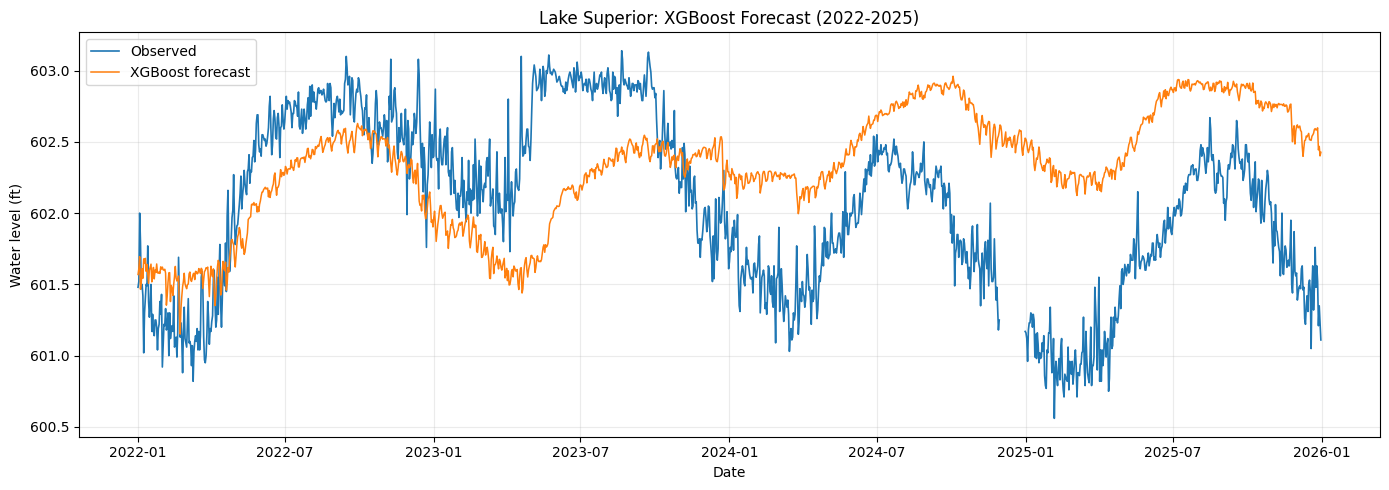

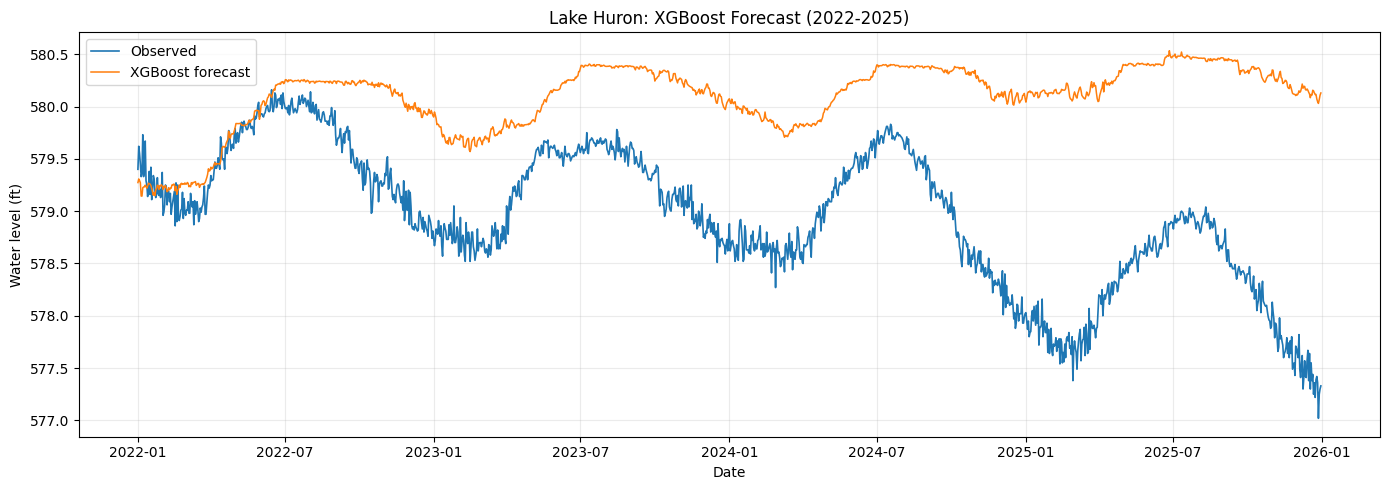

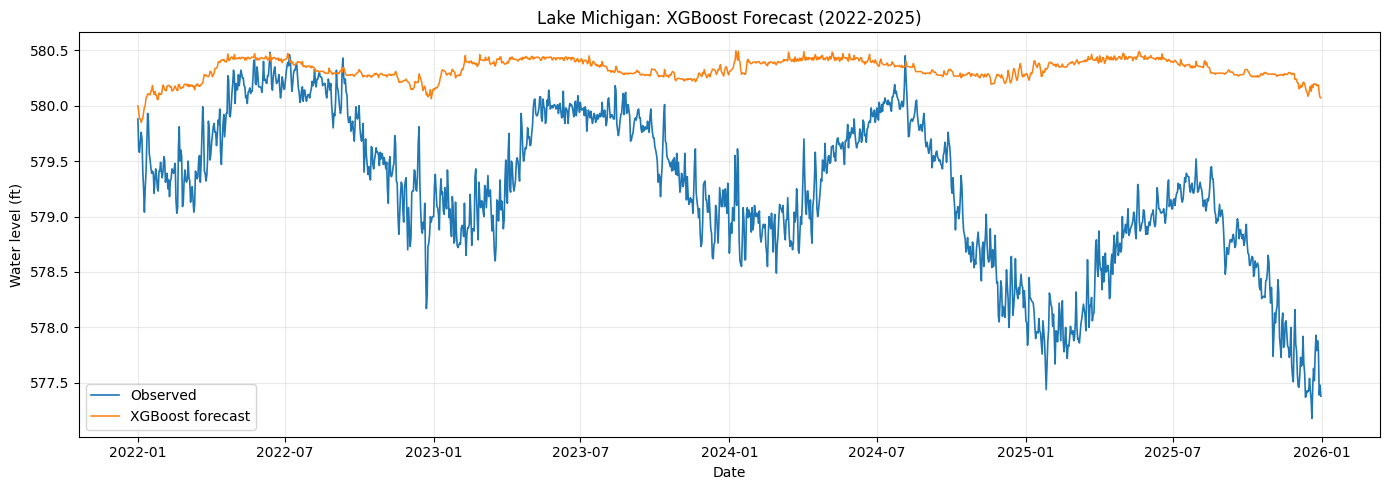

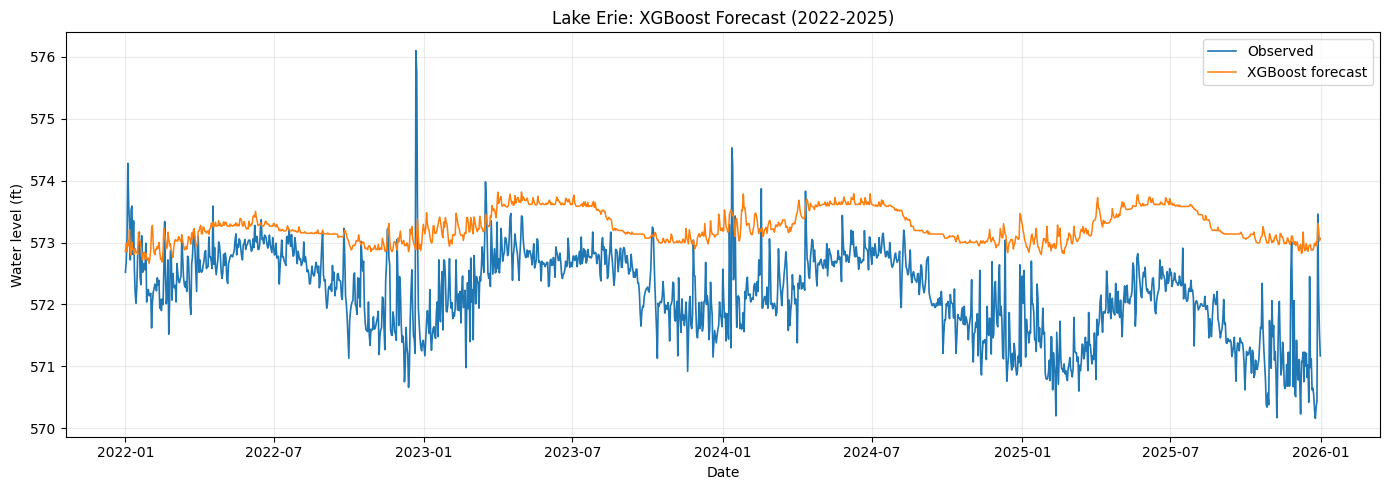

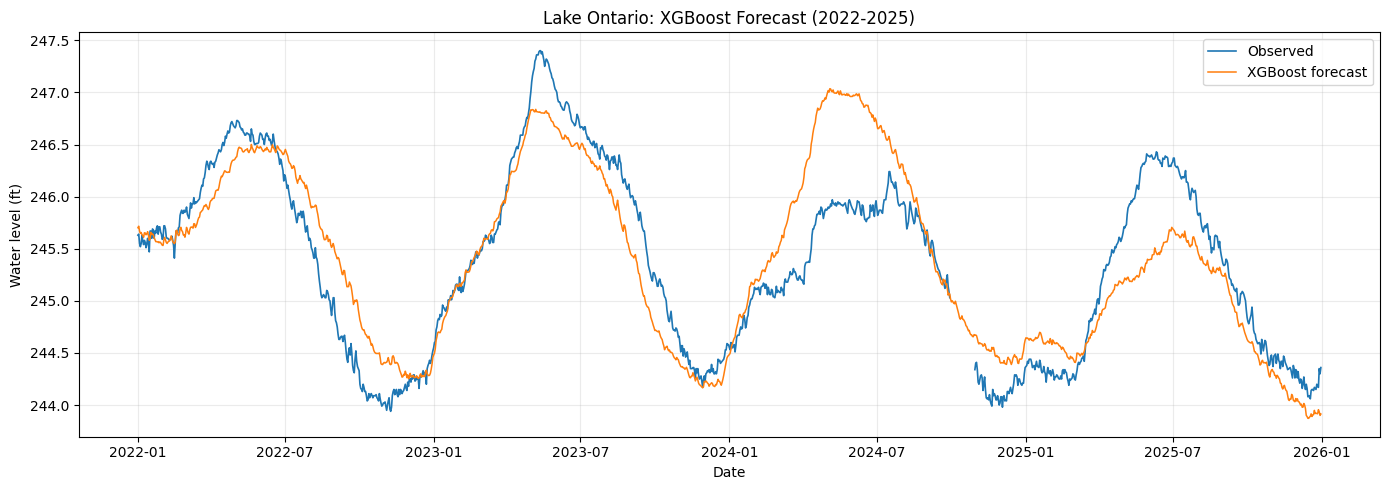

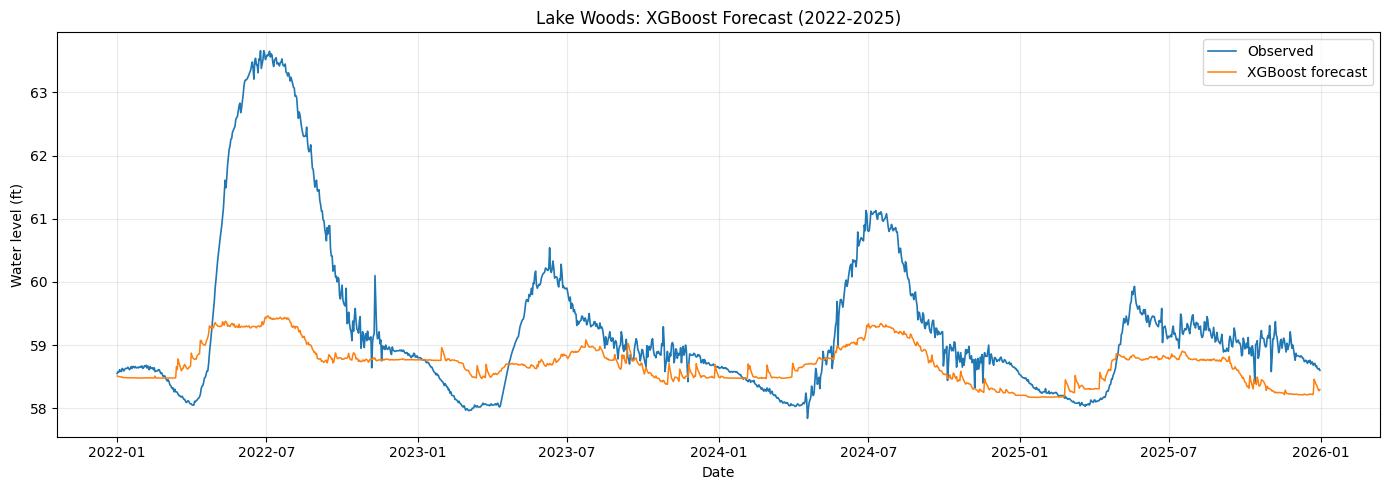

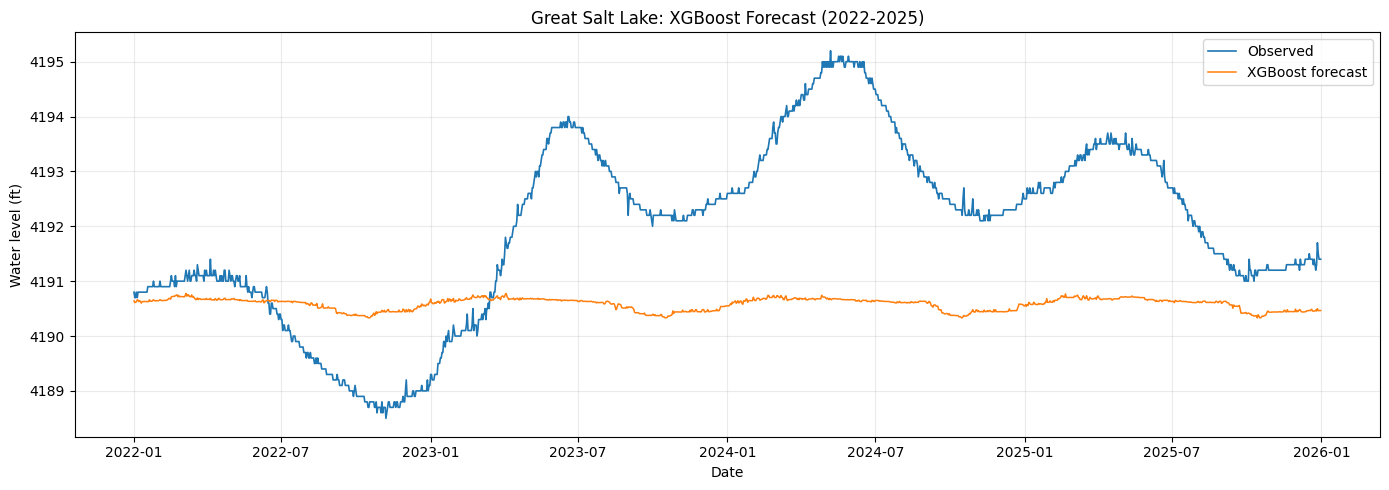

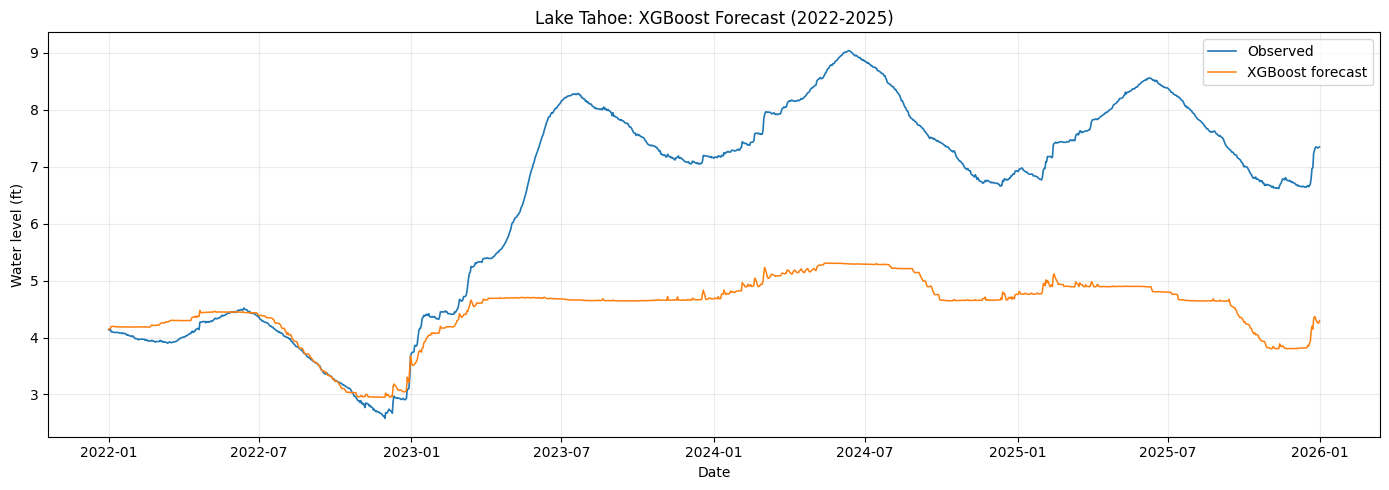

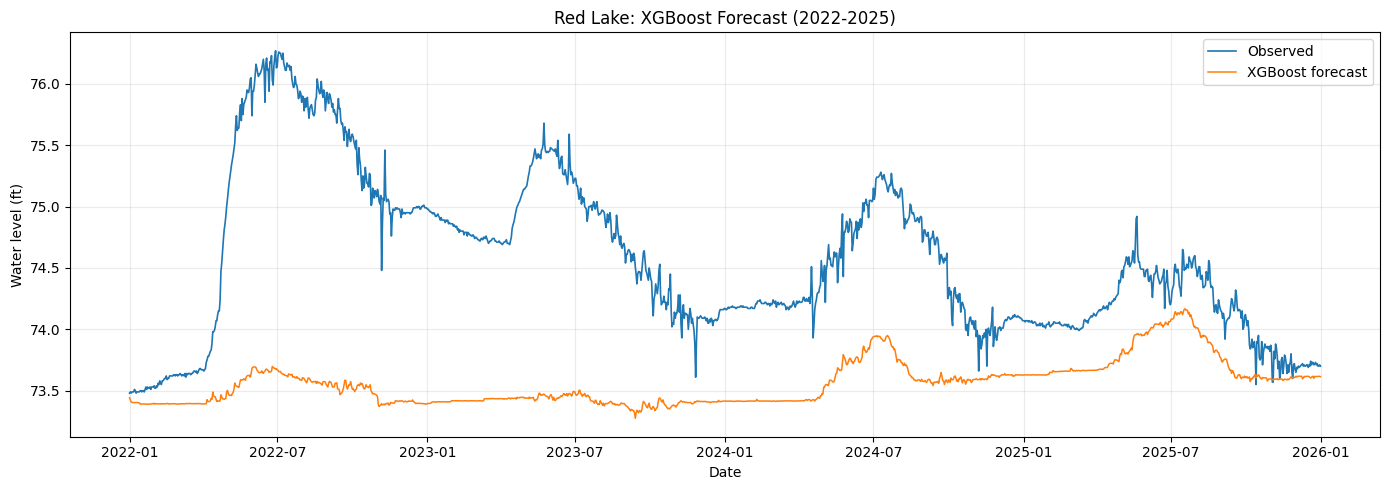

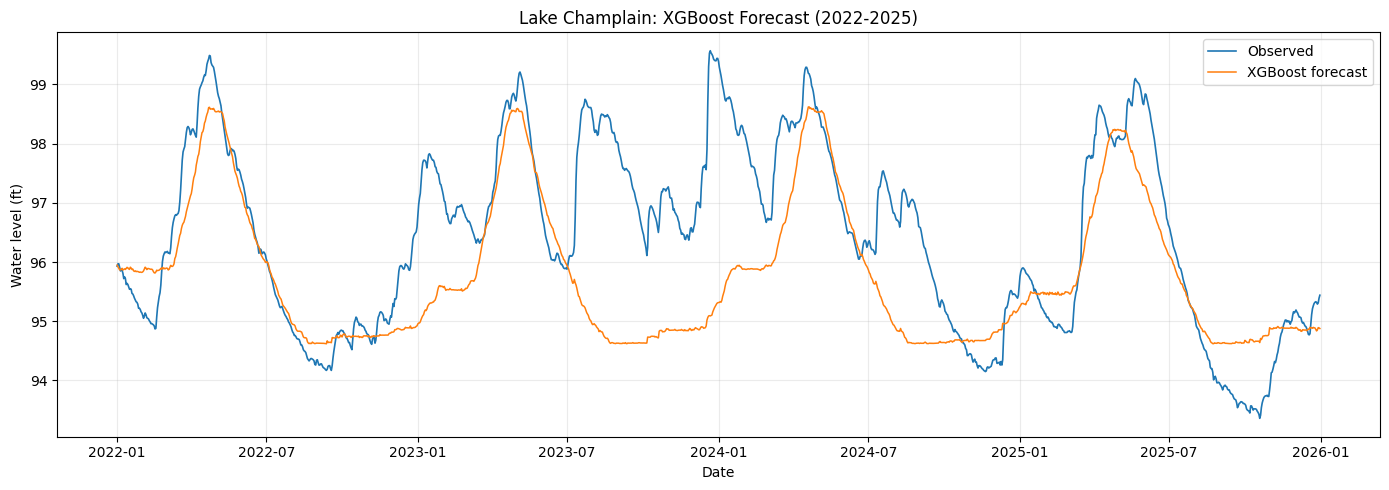

In [16]:
# Plot final XGBoost forecasts

for lake_name in lake_order:

    forecast_data = (
        xgb_final_forecasts[
            lake_name
        ]
    )

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        forecast_data.index,
        forecast_data["Actual"],
        label="Observed",
        linewidth=1.2
    )

    plt.plot(
        forecast_data.index,
        forecast_data[
            "XGBoost Forecast"
        ],
        label="XGBoost forecast",
        linewidth=1.1
    )

    plt.title(
        f"{lake_name}: XGBoost Forecast (2022-2025)"
    )

    plt.xlabel("Date")
    plt.ylabel("Water level (ft)")
    plt.legend()
    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

## 6.Final Model Comparison

In [17]:
# Load the audited statistical forecasting results

statistical_results_file = (
    forecast_output_dir
    / "all_lakes_final_test_results.csv"
)


if not statistical_results_file.exists():

    raise FileNotFoundError(
        "Audited ERP-2 final-test results were not found: "
        f"{statistical_results_file.resolve()}"
    )


statistical_summary = pd.read_csv(
    statistical_results_file
)


required_statistical_columns = {
    "Lake",
    "Preferred Model",
    "RMSE",
    "MAE",
    "R2",
    "NRMSE",
    "Seasonal Naive RMSE",
    "Seasonal Naive MAE",
    "Seasonal Naive R2",
    "Seasonal Naive NRMSE",
    "N_test"
}


missing_statistical_columns = (
    required_statistical_columns
    - set(statistical_summary.columns)
)


if missing_statistical_columns:

    raise ValueError(
        "Missing ERP-2 result columns: "
        f"{sorted(missing_statistical_columns)}"
    )


print(
    "Audited ERP-2 final-test results loaded."
)

display(
    statistical_summary[
        [
            "Lake",
            "Preferred Model",
            "RMSE",
            "Seasonal Naive RMSE",
            "N_test"
        ]
    ]
)

Audited ERP-2 final-test results loaded.


,Lake,Preferred Model,RMSE,Seasonal Naive RMSE,N_test
0,Lake Superior,Fourier-only,0.587633,0.606074,1430
1,Lake Huron,Fourier-only,1.037426,1.558199,1461
2,Lake Michigan,Fourier-only,1.393306,1.552837,1461
3,Lake Erie,Fourier-only,0.575391,1.144268,1461
4,Lake Ontario,Fourier-only,0.933800,1.044925,1431
5,Lake Woods,Fourier-only,1.063212,1.400099,1461
6,Great Salt Lake,Fourier-only,2.962064,1.602744,1461
7,Lake Champlain,Fourier-only,1.141995,1.693726,1461
8,Red Lake,Fourier-only,0.906817,1.040942,1461
9,Lake Tahoe,Fourier-only,2.276827,2.777971,1461


In [18]:
# Prepare statistical and XGBoost results for comparison

statistical_comparison = (
    statistical_summary[
        [
            "Lake",
            "Preferred Model",
            "RMSE",
            "MAE",
            "R2",
            "NRMSE",
            "N_test",
            "Seasonal Naive RMSE",
            "Seasonal Naive MAE",
            "Seasonal Naive R2",
            "Seasonal Naive NRMSE"
        ]
    ]
    .rename(
        columns={
            "RMSE":
                "Statistical RMSE",
            "MAE":
                "Statistical MAE",
            "R2":
                "Statistical R2",
            "NRMSE":
                "Statistical NRMSE",
            "N_test":
                "Statistical N_test"
        }
    )
)


xgb_comparison = (
    xgb_final_summary[
        [
            "Lake",
            "RMSE",
            "MAE",
            "R2",
            "NRMSE",
            "N_test"
        ]
    ]
    .rename(
        columns={
            "RMSE":
                "XGBoost RMSE",
            "MAE":
                "XGBoost MAE",
            "R2":
                "XGBoost R2",
            "NRMSE":
                "XGBoost NRMSE",
            "N_test":
                "XGBoost N_test"
        }
    )
)


ten_lake_model_comparison = (
    statistical_comparison
    .merge(
        xgb_comparison,
        on="Lake",
        how="inner",
        validate="one_to_one"
    )
)


ten_lake_model_comparison[
    "Lake"
] = pd.Categorical(
    ten_lake_model_comparison[
        "Lake"
    ],
    categories=lake_order,
    ordered=True
)


ten_lake_model_comparison = (
    ten_lake_model_comparison
    .sort_values("Lake")
    .reset_index(drop=True)
)


display(
    ten_lake_model_comparison[
        [
            "Lake",
            "Preferred Model",
            "Seasonal Naive RMSE",
            "Statistical RMSE",
            "XGBoost RMSE",
            "Statistical N_test",
            "XGBoost N_test"
        ]
    ]
)

,Lake,Preferred Model,Seasonal Naive RMSE,Statistical RMSE,XGBoost RMSE,Statistical N_test,XGBoost N_test
0,Lake Superior,Fourier-only,0.606074,0.587633,0.709694,1430,1430
1,Lake Huron,Fourier-only,1.558199,1.037426,1.345807,1461,1461
2,Lake Michigan,Fourier-only,1.552837,1.393306,1.275392,1461,1461
3,Lake Erie,Fourier-only,1.144268,0.575391,1.224334,1461,1461
4,Lake Ontario,Fourier-only,1.044925,0.933800,0.438907,1431,1431
5,Lake Woods,Fourier-only,1.400099,1.063212,1.207785,1461,1461
6,Great Salt Lake,Fourier-only,1.602744,2.962064,2.095651,1461,1461
7,Lake Tahoe,Fourier-only,2.777971,2.276827,2.378245,1461,1461
8,Red Lake,Fourier-only,1.040942,0.906817,1.213085,1461,1461
9,Lake Champlain,Fourier-only,1.693726,1.141995,1.348553,1461,1461


In [19]:
# Check whether statistical and XGBoost models
# were evaluated on the same number of observed test dates

ten_lake_model_comparison[
    "Evaluation N Match"
] = (
    ten_lake_model_comparison[
        "Statistical N_test"
    ]
    ==
    ten_lake_model_comparison[
        "XGBoost N_test"
    ]
)


display(
    ten_lake_model_comparison[
        [
            "Lake",
            "Statistical N_test",
            "XGBoost N_test",
            "Evaluation N Match"
        ]
    ]
)


if not ten_lake_model_comparison[
    "Evaluation N Match"
].all():

    print(
        "Warning: Some models were evaluated "
        "on different numbers of test observations. "
        "These lakes should be checked before making "
        "direct RMSE comparisons."
    )

,Lake,Statistical N_test,XGBoost N_test,Evaluation N Match
0,Lake Superior,1430,1430,True
1,Lake Huron,1461,1461,True
2,Lake Michigan,1461,1461,True
3,Lake Erie,1461,1461,True
4,Lake Ontario,1431,1431,True
5,Lake Woods,1461,1461,True
6,Great Salt Lake,1461,1461,True
7,Lake Tahoe,1461,1461,True
8,Red Lake,1461,1461,True
9,Lake Champlain,1461,1461,True


In [20]:
# Identify the lowest-RMSE model for each lake

rmse_columns = [
    "Seasonal Naive RMSE",
    "Statistical RMSE",
    "XGBoost RMSE"
]


def identify_lowest_rmse_model(
    row
):

    lowest_column = (
        row[
            rmse_columns
        ]
        .astype(float)
        .idxmin()
    )

    if (
        lowest_column
        == "Seasonal Naive RMSE"
    ):

        return "Seasonal Naive"

    if (
        lowest_column
        == "XGBoost RMSE"
    ):

        return "XGBoost"

    return row[
        "Preferred Model"
    ]


ten_lake_model_comparison[
    "Lowest-RMSE Model"
] = (
    ten_lake_model_comparison
    .apply(
        identify_lowest_rmse_model,
        axis=1
    )
)


ten_lake_model_comparison[
    "Lowest RMSE"
] = (
    ten_lake_model_comparison[
        rmse_columns
    ]
    .min(
        axis=1
    )
)


ten_lake_final_table = (
    ten_lake_model_comparison[
        [
            "Lake",
            "Preferred Model",
            "Seasonal Naive RMSE",
            "Statistical RMSE",
            "XGBoost RMSE",
            "Lowest-RMSE Model",
            "Lowest RMSE"
        ]
    ]
    .copy()
)


display(
    ten_lake_final_table
)

,Lake,Preferred Model,Seasonal Naive RMSE,Statistical RMSE,XGBoost RMSE,Lowest-RMSE Model,Lowest RMSE
0,Lake Superior,Fourier-only,0.606074,0.587633,0.709694,Fourier-only,0.587633
1,Lake Huron,Fourier-only,1.558199,1.037426,1.345807,Fourier-only,1.037426
2,Lake Michigan,Fourier-only,1.552837,1.393306,1.275392,XGBoost,1.275392
3,Lake Erie,Fourier-only,1.144268,0.575391,1.224334,Fourier-only,0.575391
4,Lake Ontario,Fourier-only,1.044925,0.933800,0.438907,XGBoost,0.438907
5,Lake Woods,Fourier-only,1.400099,1.063212,1.207785,Fourier-only,1.063212
6,Great Salt Lake,Fourier-only,1.602744,2.962064,2.095651,Seasonal Naive,1.602744
7,Lake Tahoe,Fourier-only,2.777971,2.276827,2.378245,Fourier-only,2.276827
8,Red Lake,Fourier-only,1.040942,0.906817,1.213085,Fourier-only,0.906817
9,Lake Champlain,Fourier-only,1.693726,1.141995,1.348553,Fourier-only,1.141995


In [21]:
# Count the lowest-RMSE model across the ten lakes

lowest_rmse_model_counts = (
    ten_lake_final_table[
        "Lowest-RMSE Model"
    ]
    .value_counts()
    .rename_axis("Model")
    .reset_index(
        name="Number of Lakes"
    )
)


display(
    lowest_rmse_model_counts
)

,Model,Number of Lakes
0,Fourier-only,7
1,XGBoost,2
2,Seasonal Naive,1


In [22]:
# Load the audited VAR and VARX final results

var_results_file = (
    forecast_output_dir
    / "var_vs_varx_final.csv"
)


if not var_results_file.exists():

    raise FileNotFoundError(
        "Audited ERP-3 VAR/VARX results were not found: "
        f"{var_results_file.resolve()}"
    )


var_comparison = pd.read_csv(
    var_results_file
)

required_var_columns = {
    "Lake",
    "VAR RMSE",
    "VAR MAE",
    "VAR R2",
    "VAR NRMSE",
    "VAR N_test",
    "VARX RMSE",
    "VARX MAE",
    "VARX R2",
    "VARX NRMSE",
    "VARX N_test"
}


missing_var_columns = (
    required_var_columns
    - set(var_comparison.columns)
)


if missing_var_columns:

    raise ValueError(
        "Missing ERP-3 result columns: "
        f"{sorted(missing_var_columns)}"
    )


display(
    var_comparison
)

,Lake,VAR RMSE,VAR MAE,VAR R2,VAR NRMSE,VAR N_test,VARX RMSE,VARX MAE,VARX R2,VARX NRMSE,VARX N_test,VARX RMSE Improvement (%),Evaluation N Match
0,Lake Superior,0.925008,0.784330,-1.352488,1.533246,1430,2.276077,2.175226,-13.243293,3.772709,1430,-146.060260,True
1,Lake Huron,1.005580,0.780294,-1.437335,1.560662,1461,1.091918,0.994736,-1.873837,1.694659,1461,-8.585916,True
2,Lake Michigan,1.068493,0.825357,-1.447100,1.563785,1461,0.810252,0.688214,-0.407178,1.185839,1461,24.168660,True
3,Lake Erie,1.046072,0.817298,-1.370537,1.539128,1461,0.513488,0.396412,0.428805,0.755516,1461,50.912740,True
4,Lake Ontario,0.929121,0.767865,-0.157716,1.075596,1431,1.220130,0.928705,-0.996502,1.412483,1431,-31.320914,True


In [23]:
# Create the extended Great Lakes model comparison

great_lakes = [
    "Lake Superior",
    "Lake Huron",
    "Lake Michigan",
    "Lake Erie",
    "Lake Ontario"
]


great_lakes_extended_comparison = (
    ten_lake_model_comparison[
        ten_lake_model_comparison[
            "Lake"
        ].isin(
            great_lakes
        )
    ]
    .merge(
        var_comparison,
        on="Lake",
        how="left",
        validate="one_to_one"
    )
)


great_lakes_extended_comparison[
    "Lake"
] = pd.Categorical(
    great_lakes_extended_comparison[
        "Lake"
    ],
    categories=great_lakes,
    ordered=True
)


great_lakes_extended_comparison = (
    great_lakes_extended_comparison
    .sort_values("Lake")
    .reset_index(drop=True)
)


display(
    great_lakes_extended_comparison[
        [
            "Lake",
            "Seasonal Naive RMSE",
            "Statistical RMSE",
            "XGBoost RMSE",
            "VAR RMSE",
            "VARX RMSE"
        ]
    ]
)

display(
    great_lakes_extended_comparison[
        [
            "Lake",
            "Statistical N_test",
            "XGBoost N_test",
            "VAR N_test",
            "VARX N_test"
        ]
    ]
)

,Lake,Seasonal Naive RMSE,Statistical RMSE,XGBoost RMSE,VAR RMSE,VARX RMSE
0,Lake Superior,0.606074,0.587633,0.709694,0.925008,2.276077
1,Lake Huron,1.558199,1.037426,1.345807,1.005580,1.091918
2,Lake Michigan,1.552837,1.393306,1.275392,1.068493,0.810252
3,Lake Erie,1.144268,0.575391,1.224334,1.046072,0.513488
4,Lake Ontario,1.044925,0.933800,0.438907,0.929121,1.220130


,Lake,Statistical N_test,XGBoost N_test,VAR N_test,VARX N_test
0,Lake Superior,1430,1430,1430,1430
1,Lake Huron,1461,1461,1461,1461
2,Lake Michigan,1461,1461,1461,1461
3,Lake Erie,1461,1461,1461,1461
4,Lake Ontario,1431,1431,1431,1431


In [24]:
# Identify the lowest-RMSE model for each Great Lake

great_lakes_rmse_columns = [
    "Seasonal Naive RMSE",
    "Statistical RMSE",
    "XGBoost RMSE",
    "VAR RMSE",
    "VARX RMSE"
]


def identify_great_lakes_lowest_rmse_model(
    row
):

    lowest_column = (
        row[
            great_lakes_rmse_columns
        ]
        .astype(float)
        .idxmin()
    )

    if (
        lowest_column
        == "Seasonal Naive RMSE"
    ):

        return "Seasonal Naive"

    if (
        lowest_column
        == "Statistical RMSE"
    ):

        return row[
            "Preferred Model"
        ]

    if (
        lowest_column
        == "XGBoost RMSE"
    ):

        return "XGBoost"

    if (
        lowest_column
        == "VAR RMSE"
    ):

        return "VAR"

    return "VARX"


great_lakes_extended_comparison[
    "Lowest-RMSE Model"
] = (
    great_lakes_extended_comparison
    .apply(
        identify_great_lakes_lowest_rmse_model,
        axis=1
    )
)


great_lakes_extended_comparison[
    "Lowest RMSE"
] = (
    great_lakes_extended_comparison[
        great_lakes_rmse_columns
    ]
    .min(
        axis=1
    )
)


great_lakes_final_table = (
    great_lakes_extended_comparison[
        [
            "Lake",
            "Seasonal Naive RMSE",
            "Statistical RMSE",
            "XGBoost RMSE",
            "VAR RMSE",
            "VARX RMSE",
            "Lowest-RMSE Model",
            "Lowest RMSE"
        ]
    ]
    .copy()
)


display(
    great_lakes_final_table
)

,Lake,Seasonal Naive RMSE,Statistical RMSE,XGBoost RMSE,VAR RMSE,VARX RMSE,Lowest-RMSE Model,Lowest RMSE
0,Lake Superior,0.606074,0.587633,0.709694,0.925008,2.276077,Fourier-only,0.587633
1,Lake Huron,1.558199,1.037426,1.345807,1.005580,1.091918,VAR,1.005580
2,Lake Michigan,1.552837,1.393306,1.275392,1.068493,0.810252,VARX,0.810252
3,Lake Erie,1.144268,0.575391,1.224334,1.046072,0.513488,VARX,0.513488
4,Lake Ontario,1.044925,0.933800,0.438907,0.929121,1.220130,XGBoost,0.438907


In [25]:
# Verify common final-test evaluation sample sizes
# across all Great Lakes forecasting models

great_lakes_n_check = (
    great_lakes_extended_comparison[
        [
            "Lake",
            "Statistical N_test",
            "XGBoost N_test",
            "VAR N_test",
            "VARX N_test"
        ]
    ]
    .copy()
)


great_lakes_n_check[
    "All N Match"
] = (
    (
        great_lakes_n_check[
            "Statistical N_test"
        ]
        ==
        great_lakes_n_check[
            "XGBoost N_test"
        ]
    )
    &
    (
        great_lakes_n_check[
            "Statistical N_test"
        ]
        ==
        great_lakes_n_check[
            "VAR N_test"
        ]
    )
    &
    (
        great_lakes_n_check[
            "Statistical N_test"
        ]
        ==
        great_lakes_n_check[
            "VARX N_test"
        ]
    )
)


display(
    great_lakes_n_check
)


if not great_lakes_n_check[
    "All N Match"
].all():

    raise ValueError(
        "Great Lakes models were not evaluated "
        "on the same number of observed test dates."
    )


print(
    "Great Lakes cross-model evaluation sample sizes match."
)

,Lake,Statistical N_test,XGBoost N_test,VAR N_test,VARX N_test,All N Match
0,Lake Superior,1430,1430,1430,1430,True
1,Lake Huron,1461,1461,1461,1461,True
2,Lake Michigan,1461,1461,1461,1461,True
3,Lake Erie,1461,1461,1461,1461,True
4,Lake Ontario,1431,1431,1431,1431,True


Great Lakes cross-model evaluation sample sizes match.


In [26]:
# Export final XGBoost and cross-model results

xgb_final_summary.to_csv(
    forecast_output_dir
    / "xgboost_final_test_results.csv",
    index=False
)


ten_lake_model_comparison.to_csv(
    forecast_output_dir
    / "ten_lake_final_model_comparison.csv",
    index=False
)


great_lakes_extended_comparison.to_csv(
    forecast_output_dir
    / "great_lakes_extended_model_comparison.csv",
    index=False
)


print(
    "Final ERP-4 outputs exported successfully."
)

print(
    forecast_output_dir.resolve()
)

Final ERP-4 outputs exported successfully.
D:\Postgraduate\DATA72000 Data Science Extended Research Project\ERP Final\outputs\forecasting_results
